In [26]:
import math
from io import StringIO

import numpy as np
import pandas as pd
import requests
import optuna
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import itertools
import time
import copy
from sklearn.model_selection import TimeSeriesSplit

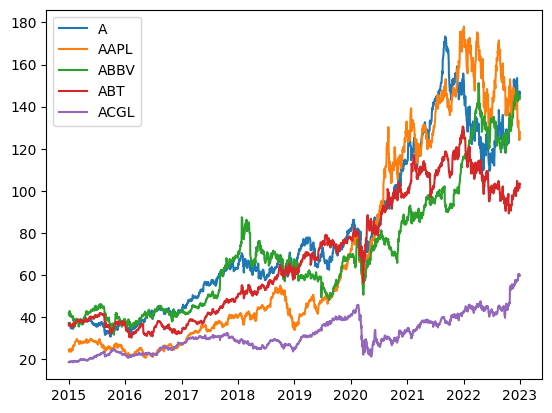

In [27]:
open_prices_interp = pd.read_csv(
    "/Users/stephwenninger/Desktop/LSE/ST457/Group Project/open_prices_interp.csv",
    index_col=0,
    parse_dates=True
)
# just to get a visualization that it looks right
for i in open_prices_interp.columns[:5]:
  prices = open_prices_interp[i]
  plt.plot(prices.index, prices.values, label=f'{i}')
plt.legend()

In [28]:
# into numpy
x = open_prices_interp.to_numpy()

(460, 460)


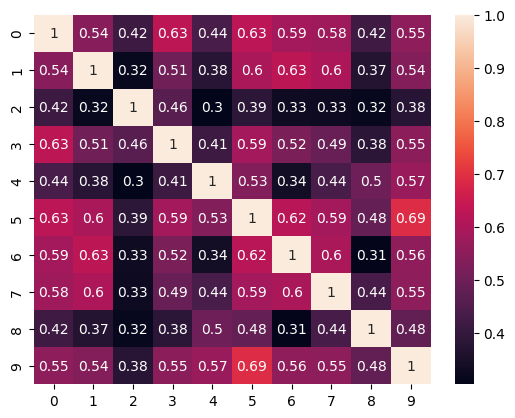

In [29]:
# Make data more stationary by using log and diff, so we get the relative changes  (I thought that an LSTM model could predict non-stationary time-series, but it was a bit tough for it)
x_returns = np.diff(np.log(x),axis=0)

# calculate the correlation
corr_ = np.corrcoef(x_returns.T)
ax = sns.heatmap(corr_[:10,:10], annot=True)
print(corr_.shape)

In [30]:
set_of_sector = set()
set_of_industry = set()
for val in firm_industry_dict.values():
  sector, industry = val
  set_of_sector.add(sector)
  set_of_industry.add(industry)

# make adjacency matrix
firm_tickers = tickers_with_data # I have removed  '^GSPC', so no difference now
N = len(firm_tickers)
A = np.zeros((N, N, 3)) # 2 types of relation, industry and sector

for i, ti in enumerate(firm_tickers):
    for j, tj in enumerate(firm_tickers):
        if ti == tj:
            continue
        if firm_industry_dict[ti][1] == firm_industry_dict[tj][1]:
            A[i, j, 0] = 1   # connection type 1
        elif firm_industry_dict[ti][0] == firm_industry_dict[tj][0]:
            A[i, j, 1] = 1   # connection type 2
# add the correlation matrix to adjacency matrix
A[:,:,2] = corr_  # this correlation is on the entire period, perhaps just do it for training period

NameError: name 'firm_industry_dict' is not defined

# RQ1
## Prepare data for LSTM

In [31]:
# create moving average features, what they do in the paper
windows = [5, 10, 20, 30]

def moving_average(a, window):
    return np.apply_along_axis(lambda x: np.convolve(x, np.ones(window)/window, mode='valid'), axis=0, arr=a)

ma_dict = {w: moving_average(x_returns, w) for w in windows}
min_T = min(ma.shape[0] for ma in ma_dict.values())
x_trim = x_returns[-min_T:]
ma_trimmed = [ma_dict[w][-min_T:] for w in windows]
features = np.stack([x_trim] + ma_trimmed, axis=-1)

f'(Time point, firm, type of price)= {features.shape}'

'(Time point, firm, type of price)= (1984, 460, 5)'

## Create training, validation and test data

In [32]:
def create_data(batch_size=32, flatten_data = True, shuffle_train= True):
  # target all prices at time t
  target = features[:, :, 0]

  # split up the data
  n = len(target)
  train_end = n // 2
  val_end = train_end + n // 4
  train_raw = features[:train_end,:,:]
  val_raw   = features[train_end:val_end,:,:]
  test_raw  = features[val_end:,:, :]

  # Get original shapes for reshaping back
  train_shape = train_raw.shape
  val_shape = val_raw.shape
  test_shape = test_raw.shape

  # Reshape 3D data to 2D for StandardScaler (combine first two dimensions)
  train_reshaped = train_raw.reshape(-1, train_shape[-1])
  val_reshaped = val_raw.reshape(-1, val_shape[-1])
  test_reshaped = test_raw.reshape(-1, test_shape[-1])
  sc = StandardScaler()
  train_scaled_reshaped = sc.fit_transform(train_reshaped)
  val_scaled_reshaped   = sc.transform(val_reshaped)
  test_scaled_reshaped  = sc.transform(test_reshaped)

  # Reshape back to 3D after scaling
  train_scaled = train_scaled_reshaped.reshape(train_shape)
  val_scaled   = val_scaled_reshaped.reshape(val_shape)
  test_scaled  = test_scaled_reshaped.reshape(test_shape)

  # Concatenate along the time dimension (axis=0)
  full_scaled = np.concatenate((train_scaled, val_scaled, test_scaled), axis=0)

  seq_len = 8
  X, y = [], []
  for i in range(seq_len, len(full_scaled)):
      X.append(full_scaled[i-seq_len:i, :,:])
      y.append(full_scaled[i, :, 0])

  X = np.array(X, dtype=np.float32)
  y = np.array(y, dtype=np.float32)

  train_idx = train_end - seq_len
  val_idx   = val_end - seq_len

  X_train, y_train = X[:train_idx], y[:train_idx]
  X_val,   y_val   = X[train_idx:val_idx], y[train_idx:val_idx]
  X_test,  y_test  = X[val_idx:], y[val_idx:]

  # keras can max input 3D and not 4D
  if flatten_data:
    (T, L, N, F) = X_train.shape
    X_train = X_train.reshape(T,L,N*F)
    (T, L, N, F) = X_val.shape
    X_val = X_val.reshape(T,L,N*F)
    (T, L, N, F) = X_test.shape
    X_test = X_test.reshape(T,L,N*F)


  # Convert to torch tensors and make into mini-batches (otherwise it can crash as it uses too much RAM)
  X_train_t = torch.tensor(X_train, dtype=torch.float32)
  X_val_t   = torch.tensor(X_val, dtype=torch.float32)
  X_test_t  = torch.tensor(X_test, dtype=torch.float32)

  y_train_t = torch.tensor(y_train, dtype=torch.float32)
  y_val_t   = torch.tensor(y_val, dtype=torch.float32)
  y_test_t  = torch.tensor(y_test, dtype=torch.float32)

  print(X_train_t.shape)  # (T_train, 8, 460, 5)
  print(y_train_t.shape)  # (T_train, 460)

  train_ds = TensorDataset(X_train_t, y_train_t)
  val_ds   = TensorDataset(X_val_t, y_val_t)
  test_ds  = TensorDataset(X_test_t, y_test_t)

  train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle_train) # this includes all the data makes it into batches
  val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
  test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
  return X_train, y_train, X_val, y_val, X_test, y_test, sc, train_loader, val_loader, test_loader

batch_size =32
X_train, y_train, X_val, y_val, X_test, y_test, sc, train_loader, val_loader, test_loader = create_data(batch_size =batch_size)

torch.Size([984, 8, 2300])
torch.Size([984, 460])


In [33]:
for x,y in train_loader:
  print(x.shape, y.shape)
  break

torch.Size([32, 8, 2300]) torch.Size([32, 460])


## Steph's attempt

The main differences to Nat's attempt are that I am using the PyTorch LSTM model (bcs I have no idea about tf, sorry), am adding a 3rd, fully connected layer and try hyperparameter tuning not with a grid, but with optuna cross validation search. 

In [34]:

#define lstm model

class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_units, output_size, dropout_rate):
        super().__init__()

        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_units,
            batch_first=True
        )
        self.dropout1 = nn.Dropout(dropout_rate)

        self.lstm2 = nn.LSTM(
            input_size=hidden_units,
            hidden_size=hidden_units * 2,
            batch_first=True
        )
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc1 = nn.Linear(hidden_units * 2, hidden_units)
        self.relu = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(hidden_units, output_size)

    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.dropout1(x)

        x, _ = self.lstm2(x)
        x = x[:, -1, :]   # last time step
        x = self.dropout2(x)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout3(x)

        x = self.fc2(x)
        return x

In [35]:
# training and evaluation functions, we will use these in the hyperparameter tuning loop and for the final evaluation on the test set
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    n = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        batch_size = X_batch.size(0)
        running_loss += loss.item() * batch_size
        n += batch_size

    return running_loss / n


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    n = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            batch_size = X_batch.size(0)
            running_loss += loss.item() * batch_size
            n += batch_size

    return running_loss / n

In [36]:
# for hyperparameter tuning, we will use optuna to do a cross validation search on the training and validation set, 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def objective(trial):
    hidden_units = trial.suggest_int("lstm_units", 64, 256, step=64)
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 5e-4, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])
    epochs = trial.suggest_int("epochs", 15, 40)
    patience = trial.suggest_int("patience", 5, 10)

    # rebuild loaders with trial batch size
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val, dtype=torch.float32)
    y_val_t   = torch.tensor(y_val, dtype=torch.float32)

    train_ds = TensorDataset(X_train_t, y_train_t)
    val_ds   = TensorDataset(X_val_t, y_val_t)

    train_loader_trial = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
    val_loader_trial   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = LSTMRegressor(
        input_size=X_train.shape[2],
        hidden_units=hidden_units,
        output_size=y_train.shape[1],
        dropout_rate=dropout_rate
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    best_val_loss = float("inf")
    best_state_dict = None
    patience_counter = 0

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader_trial, criterion, optimizer, device)
        val_loss = evaluate(model, val_loader_trial, criterion, device)

        trial.report(val_loss, step=epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return best_val_loss

In [37]:
# run the Optuna study
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Best trial:")
print("  Value:", study.best_trial.value)
print("  Params:")
for k, v in study.best_trial.params.items():
    print(f"    {k}: {v}")

[I 2026-04-14 18:21:02,978] A new study created in memory with name: no-name-00c5dfd1-0668-40c9-94f1-c950532388eb


[I 2026-04-14 18:21:24,439] Trial 0 finished with value: 2.6140296613016436 and parameters: {'lstm_units': 192, 'dropout_rate': 0.3450631292287064, 'learning_rate': 0.0005288130161810685, 'batch_size': 64, 'epochs': 27, 'patience': 8}. Best is trial 0 with value: 2.6140296613016436.
[I 2026-04-14 18:21:41,457] Trial 1 finished with value: 2.6134280273991246 and parameters: {'lstm_units': 256, 'dropout_rate': 0.3251220836030049, 'learning_rate': 0.000905151771821123, 'batch_size': 128, 'epochs': 21, 'patience': 6}. Best is trial 1 with value: 2.6134280273991246.
[I 2026-04-14 18:21:55,570] Trial 2 finished with value: 2.6145219687492616 and parameters: {'lstm_units': 128, 'dropout_rate': 0.27818681428991565, 'learning_rate': 0.0008559395815267287, 'batch_size': 32, 'epochs': 24, 'patience': 8}. Best is trial 1 with value: 2.6134280273991246.
[I 2026-04-14 18:22:21,501] Trial 3 finished with value: 2.613591424880489 and parameters: {'lstm_units': 256, 'dropout_rate': 0.23359274790926876,

Best trial:
  Value: 2.6134280273991246
  Params:
    lstm_units: 256
    dropout_rate: 0.3251220836030049
    learning_rate: 0.000905151771821123
    batch_size: 128
    epochs: 21
    patience: 6


In [38]:
# best Optuna params (this could have been done nicer, I know, I will fix it later)
best_params = study.best_trial.params

In [41]:
# now we can train the final model on the entire training and validation set with the best hyperparameters, 
# and evaluate it on the test set

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_params = study.best_trial.params

input_size = X_train.shape[2]
output_size = y_train.shape[1]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
y_val_t   = torch.tensor(y_val, dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t, y_val_t)

train_loader_final = DataLoader(
    train_ds,
    batch_size=best_params["batch_size"],
    shuffle=False
)

val_loader_final = DataLoader(
    val_ds,
    batch_size=best_params["batch_size"],
    shuffle=False
)

model = LSTMRegressor(
    input_size=input_size,
    hidden_units=best_params["lstm_units"],
    output_size=output_size,
    dropout_rate=best_params["dropout_rate"]
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=best_params["learning_rate"])

In [43]:

import copy

def train_with_validation(model, train_loader, val_loader, criterion, optimizer, device, epochs=100, patience=10):
    best_val_loss = float("inf")
    best_state_dict = None
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_loss": []
    }

    for epoch in range(epochs):
        # training
        model.train()
        running_train_loss = 0.0
        n_train = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

            batch_size = X_batch.size(0)
            running_train_loss += loss.item() * batch_size
            n_train += batch_size

        train_loss = running_train_loss / n_train

        # validation
        model.eval()
        running_val_loss = 0.0
        n_val = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                preds = model(X_batch)
                loss = criterion(preds, y_batch)

                batch_size = X_batch.size(0)
                running_val_loss += loss.item() * batch_size
                n_val += batch_size

        val_loss = running_val_loss / n_val

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, history, best_val_loss

model, history, best_val_loss = train_with_validation(
    model=model,
    train_loader=train_loader_final,
    val_loader=val_loader_final,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=best_params["epochs"],
    patience=best_params["patience"]
)

Epoch 1/21 | Train Loss: 1.0048 | Val Loss: 2.6139
Epoch 2/21 | Train Loss: 1.0002 | Val Loss: 2.6153
Epoch 3/21 | Train Loss: 0.9830 | Val Loss: 2.6402
Epoch 4/21 | Train Loss: 0.9642 | Val Loss: 2.6287
Epoch 5/21 | Train Loss: 0.9659 | Val Loss: 2.6267
Epoch 6/21 | Train Loss: 0.9438 | Val Loss: 2.6297
Epoch 7/21 | Train Loss: 0.9247 | Val Loss: 2.7134
Early stopping triggered.


In [44]:
test_loss = evaluate(model, test_loader, criterion, device)

print("Best validation loss:", best_val_loss)
print("Test loss:", test_loss)

Best validation loss: 2.6138939549846034
Test loss: 1.554164255819013


This looks very similar to the results Nat and Mathias got, essentially the model still just overfits better and validation loss doesn't get better

model = LSTMRegressor(
    input_size=input_size,
    hidden_units=best_params["lstm_units"],
    output_size=output_size,
    dropout_rate=best_params["dropout_rate"]
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=best_params["learning_rate"])

print(model)